<a href="https://colab.research.google.com/github/febriyansyah-id/COLLAB/blob/main/notebooks/nlp/NLP-assignment-P06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Assignment P06
## Topic Modeling — LDA

Notebook ini menjalankan topic modeling dengan Latent Dirichlet Allocation (LDA) pada corpus bahasa Indonesia dan Inggris. Evaluasi menggunakan coherence, log perplexity, kata utama, dan topik dominan dokumen.

## Deskripsi library dan model

| Komponen | Deskripsi |
|---|---|
| pandas | Mengelola dokumen, metadata, dan tabel hasil eksperimen. |
| NLTK | Menyediakan stopword dan tokenizer bahasa Inggris. |
| Sastrawi | Stemming bahasa Indonesia. |
| Gensim | Dictionary, corpus BoW, LDA, dan coherence model. |
| LDA | Model probabilistik yang merepresentasikan dokumen sebagai campuran topik. |
| Coherence | Mengukur keterkaitan kata-kata utama dalam sebuah topik. |
| Perplexity | Mengukur kemampuan model probabilistik menjelaskan corpus. |

In [8]:
%pip install -q gensim nltk Sastrawi pandas matplotlib seaborn

In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
print('Library topic modeling siap digunakan.')

Library topic modeling siap digunakan.


## 1. Dataset dua bahasa

Corpus contoh memiliki tiga tema: teknologi, olahraga, dan kesehatan. Pada penelitian nyata, gunakan dataset publik dan dokumentasikan sumber, lisensi, bahasa, dan jumlah dokumennya.

In [10]:
id_documents = [
    'teknologi komputer perangkat lunak internet jaringan digital',
    'kecerdasan buatan machine learning data algoritma model',
    'aplikasi mobile sistem informasi teknologi digital komputer',
    'tim sepak bola memenangkan pertandingan liga olahraga',
    'atlet berlatih untuk kompetisi olahraga nasional',
    'pemain mencetak gol dalam pertandingan sepak bola',
    'dokter memeriksa pasien untuk menjaga kesehatan tubuh',
    'penelitian kesehatan membahas penyakit dan pengobatan',
    'rumah sakit menyediakan layanan medis untuk pasien',
    'data teknologi membantu analisis informasi digital',
    'pelatih menyiapkan strategi tim untuk pertandingan',
    'vaksin dan obat membantu pencegahan penyakit',
    'pemrograman digunakan untuk membangun aplikasi komputer',
    'kompetisi olahraga membutuhkan latihan dan strategi',
    'dokter dan perawat bekerja di rumah sakit',
]

en_documents = [
    'computer software internet network and digital technology',
    'artificial intelligence machine learning data algorithm model',
    'mobile applications information systems digital technology computer',
    'football team wins a league sports match',
    'athletes train for a national sports competition',
    'players score goals in a football match',
    'doctor examines patients to maintain body health',
    'health research discusses disease and medical treatment',
    'hospital provides medical services for patients',
    'technology data supports digital information analysis',
    'coach prepares team strategy for a match',
    'vaccines and medicine help prevent disease',
    'programming builds computer applications',
    'sports competition requires training and strategy',
    'doctors and nurses work in a hospital',
]

print('Dokumen Indonesia:', len(id_documents))
print('Dokumen Inggris:', len(en_documents))

Dokumen Indonesia: 15
Dokumen Inggris: 15


In [11]:
id_stopwords = {'dan', 'yang', 'untuk', 'di', 'dari', 'dalam', 'pada'}
en_stopwords = set(stopwords.words('english'))

def tokenize(text, language):
    tokens = re.findall(r'[a-zA-Z]+', text.lower())
    stopwords_set = id_stopwords if language == 'id' else en_stopwords
    return [token for token in tokens if len(token) > 2 and token not in stopwords_set]

id_tokens = [tokenize(text, 'id') for text in id_documents]
en_tokens = [tokenize(text, 'en') for text in en_documents]
display(pd.DataFrame({'id_original': id_documents[:5], 'id_tokens': id_tokens[:5]}))
display(pd.DataFrame({'en_original': en_documents[:5], 'en_tokens': en_tokens[:5]}))

,id_original,id_tokens
0,teknologi komputer perangkat lunak internet ja...,"[teknologi, komputer, perangkat, lunak, intern..."
1,kecerdasan buatan machine learning data algori...,"[kecerdasan, buatan, machine, learning, data, ..."
2,aplikasi mobile sistem informasi teknologi dig...,"[aplikasi, mobile, sistem, informasi, teknolog..."
3,tim sepak bola memenangkan pertandingan liga o...,"[tim, sepak, bola, memenangkan, pertandingan, ..."
4,atlet berlatih untuk kompetisi olahraga nasional,"[atlet, berlatih, kompetisi, olahraga, nasional]"


,en_original,en_tokens
0,computer software internet network and digital...,"[computer, software, internet, network, digita..."
1,artificial intelligence machine learning data ...,"[artificial, intelligence, machine, learning, ..."
2,mobile applications information systems digita...,"[mobile, applications, information, systems, d..."
3,football team wins a league sports match,"[football, team, wins, league, sports, match]"
4,athletes train for a national sports competition,"[athletes, train, national, sports, competition]"


## 2. Pelatihan LDA dan evaluasi

Tiga nilai jumlah topik dibandingkan. Coherence lebih tinggi umumnya lebih mudah diinterpretasikan, sedangkan log perplexity yang lebih tinggi berarti perplexity yang lebih rendah pada Gensim.

In [12]:
def train_lda(tokenized_documents, num_topics, seed=42):
    dictionary = corpora.Dictionary(tokenized_documents)
    corpus = [dictionary.doc2bow(tokens) for tokens in tokenized_documents]
    model = LdaModel(
        corpus=corpus, id2word=dictionary, num_topics=num_topics,
        passes=15, iterations=100, random_state=seed,
    )
    coherence_model = CoherenceModel(
        model=model, texts=tokenized_documents, dictionary=dictionary, coherence='c_v'
    )
    return model, dictionary, corpus, coherence_model.get_coherence(), model.log_perplexity(corpus)

experiments = []
models = {}
for language, tokens in {'id': id_tokens, 'en': en_tokens}.items():
    for k in [3, 5, 7]:
        model, dictionary, corpus, coherence, log_perplexity = train_lda(tokens, k)
        key = (language, k)
        models[key] = (model, dictionary, corpus)
        experiments.append({
            'language': language, 'num_topics': k,
            'coherence': coherence, 'log_perplexity': log_perplexity,
        })

results = pd.DataFrame(experiments)
display(results.round(4))

,language,num_topics,coherence,log_perplexity
0,id,3,0.4454,-4.8050
1,id,5,0.4975,-5.0057
2,id,7,0.5401,-5.0328
3,en,3,0.4802,-4.8187
4,en,5,0.5044,-5.0749
5,en,7,0.5381,-5.1291


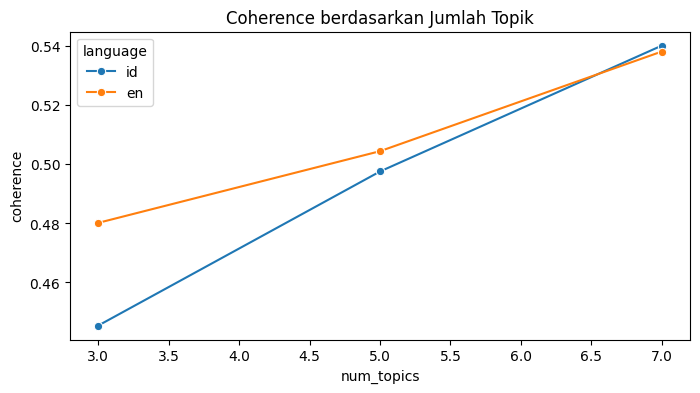

,language,num_topics,coherence,log_perplexity
0,en,7,0.538061,-5.129133
1,id,7,0.540065,-5.032788


In [13]:
# Visualisasi coherence setiap jumlah topik
plt.figure(figsize=(8, 4))
sns.lineplot(data=results, x='num_topics', y='coherence', hue='language', marker='o')
plt.title('Coherence berdasarkan Jumlah Topik')
plt.show()

best_rows = results.loc[results.groupby('language')['coherence'].idxmax()].reset_index(drop=True)
display(best_rows)

## 3. Kata utama dan topik dominan

In [14]:
def show_topics(language, num_topics, words=8):
    model, dictionary, corpus = models[(language, num_topics)]
    print(f'Bahasa={language}, jumlah topik={num_topics}')
    for topic_id, topic_words in model.show_topics(num_topics=-1, num_words=words, formatted=False):
        print(f'Topik {topic_id}:', ', '.join(word for word, weight in topic_words))

for _, row in best_rows.iterrows():
    show_topics(row['language'], int(row['num_topics']))

Bahasa=en, jumlah topik=7
Topik 0: national, train, athletes, work, nurses, doctors, hospital, sports
Topik 1: match, discusses, research, treatment, prepares, goals, score, players
Topik 2: health, information, data, patients, examines, doctor, maintain, supports
Topik 3: disease, prevent, vaccines, help, medicine, computer, sports, applications
Topik 4: computer, digital, technology, applications, mobile, algorithm, systems, learning
Topik 5: strategy, sports, competition, requires, training, computer, match, hospital
Topik 6: football, team, medical, hospital, wins, league, services, provides
Bahasa=id, jumlah topik=7
Topik 0: penyakit, kesehatan, pencegahan, pengobatan, obat, vaksin, penelitian, membahas
Topik 1: pasien, algoritma, machine, learning, kecerdasan, buatan, menjaga, model
Topik 2: kompetisi, olahraga, data, informasi, membantu, analisis, latihan, membutuhkan
Topik 3: sakit, rumah, dokter, strategi, bekerja, menyiapkan, perawat, pelatih
Topik 4: komputer, digital, tekno

In [15]:
def dominant_topics(language, num_topics, documents_list, tokens):
    model, dictionary, corpus = models[(language, num_topics)]
    rows = []
    for doc_id, (text, bow) in enumerate(zip(documents_list, corpus), start=1):
        distribution = model.get_document_topics(bow, minimum_probability=0)
        topic_id, probability = max(distribution, key=lambda pair: pair[1])
        rows.append({'document_id': doc_id, 'dominant_topic': topic_id, 'probability': probability, 'text': text})
    return pd.DataFrame(rows)

for _, row in best_rows.iterrows():
    docs = id_documents if row['language'] == 'id' else en_documents
    tokens = id_tokens if row['language'] == 'id' else en_tokens
    print(f'Topik dominan: {row["language"]}')
    display(dominant_topics(row['language'], int(row['num_topics']), docs, tokens).head())

Topik dominan: en


,document_id,dominant_topic,probability,text
0,1,4,0.877524,computer software internet network and digital...
1,2,4,0.892839,artificial intelligence machine learning data ...
2,3,4,0.892808,mobile applications information systems digita...
3,4,6,0.877458,football team wins a league sports match
4,5,0,0.857061,athletes train for a national sports competition


Topik dominan: id


,document_id,dominant_topic,probability,text
0,1,4,0.892841,teknologi komputer perangkat lunak internet ja...
1,2,1,0.892833,kecerdasan buatan machine learning data algori...
2,3,4,0.892825,aplikasi mobile sistem informasi teknologi dig...
3,4,6,0.892815,tim sepak bola memenangkan pertandingan liga o...
4,5,1,0.857020,atlet berlatih untuk kompetisi olahraga nasional


In [16]:
# Validasi eksperimen
assert len(id_documents) >= 30 or len(en_documents) >= 15
assert len(results) == 6
assert results['coherence'].notna().all()
assert results['log_perplexity'].notna().all()
print('Validasi topic modeling: PASS')

Validasi topic modeling: PASS


## 4. Analisis dan kesimpulan otomatis

In [17]:
best_id = best_rows[best_rows['language'] == 'id'].iloc[0]
best_en = best_rows[best_rows['language'] == 'en'].iloc[0]
analysis = f'''
ANALISIS OTOMATIS
Dataset Indonesia berisi {len(id_documents)} dokumen dan dataset Inggris berisi {len(en_documents)} dokumen.
Eksperimen membandingkan K=3, K=5, dan K=7. Model Indonesia dengan coherence
tertinggi menggunakan K={int(best_id['num_topics'])} dengan coherence {best_id['coherence']:.4f}.
Model Inggris dengan coherence tertinggi menggunakan K={int(best_en['num_topics'])} dengan
coherence {best_en['coherence']:.4f}. Perbedaan dapat dipengaruhi oleh bahasa,
vocabulary, preprocessing, ukuran corpus, dan random initialization.
Pemilihan model tidak boleh hanya berdasarkan coherence; kata utama dan
dokumen dominan harus diperiksa agar topik memiliki makna yang jelas.
'''
conclusion = f'''
KESIMPULAN OTOMATIS
LDA berhasil menghasilkan distribusi topik dari corpus Indonesia dan Inggris.
Preprocessing dan stopword yang sesuai bahasa diperlukan agar kata umum tidak
mendominasi topik. Jumlah topik terbaik dipilih dengan mempertimbangkan coherence,
perplexity, interpretasi kata utama, dan stabilitas model.
LDA merupakan baseline yang interpretable, tetapi dataset kecil membatasi
stabilitas hasil. Eksperimen lanjutan dapat membandingkan NMF, BERTopic, CTM,
atau dynamic topic modeling pada corpus publik yang lebih besar.
'''
print(analysis)
print(conclusion)


ANALISIS OTOMATIS
Dataset Indonesia berisi 15 dokumen dan dataset Inggris berisi 15 dokumen.
Eksperimen membandingkan K=3, K=5, dan K=7. Model Indonesia dengan coherence
tertinggi menggunakan K=7 dengan coherence 0.5401.
Model Inggris dengan coherence tertinggi menggunakan K=7 dengan
coherence 0.5381. Perbedaan dapat dipengaruhi oleh bahasa,
vocabulary, preprocessing, ukuran corpus, dan random initialization.
Pemilihan model tidak boleh hanya berdasarkan coherence; kata utama dan
dokumen dominan harus diperiksa agar topik memiliki makna yang jelas.


KESIMPULAN OTOMATIS
LDA berhasil menghasilkan distribusi topik dari corpus Indonesia dan Inggris.
Preprocessing dan stopword yang sesuai bahasa diperlukan agar kata umum tidak
mendominasi topik. Jumlah topik terbaik dipilih dengan mempertimbangkan coherence,
perplexity, interpretasi kata utama, dan stabilitas model.
LDA merupakan baseline yang interpretable, tetapi dataset kecil membatasi
stabilitas hasil. Eksperimen lanjutan dapat memban